# Phase 3 v13 - 1D-CNN Temporal Model (WITHOUT looking_down)

**Experiment:** Replace the two-stage MLP (78-dim aggregated features) with a
single 1D-CNN model that processes raw **75×13 frame-level feature sequences**.

**Key difference from MLP approach:** Instead of aggregating each 3-second window
into 6 statistics (mean/std/max/min/range/zero_crossings), we feed the raw temporal
sequence directly. This preserves the **ordering** of movements - the model can
learn that "look left then quickly look right" is different from "steady leftward gaze."

**Architecture:** Single 3-class model (not two-stage)
**Classes:** ['normal', 'head_turn', 'lateral_movement']
**Input shape:** (batch, 75, 13) - 75 time steps × 13 features per step

In [1]:
import os, io, pickle, warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
warnings.filterwarnings('ignore'); sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
import time

Device: cuda


In [2]:
DATA_DIR   = '/home/sagemaker-user/exam_proctoring_dataset'
OUTPUT_DIR = os.path.join(DATA_DIR, 'training_outputs')
POSES_DIR  = os.path.join(DATA_DIR, 'poses')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEATURES_CHECKPOINT_CANDIDATES = [
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint_filtered.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v10_checkpoint.pkl'),
    os.path.join(OUTPUT_DIR, 'features_v9_manual_clip_only_target_review_checkpoint.pkl'),
]
REVIEW_CSV_CANDIDATES = [
    os.path.join(DATA_DIR, 'review_target_person_v10', 'target_person_review.csv'),
    os.path.join(DATA_DIR, 'review_target_person_v9',  'target_person_review.csv'),
]

MERGE_MAP = {
    'normal': 'normal', 'looking_down': 'looking_down',
    'leaning_to_neighbor': 'lateral_movement', 'passing_note': 'lateral_movement',
    'looking_sideways': 'head_turn', 'talking_to_neighbor': 'head_turn',
}

SEED = 42; np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

def save_ckpt(obj, path):
    with open(path, 'wb') as f: pickle.dump(obj, f)
    print(f'  Saved: {os.path.basename(path)}')

def load_ckpt(path):
    if not os.path.exists(path): return None
    with open(path, 'rb') as f: return pickle.load(f)

def scaler_to_bytes(sc):
    buf = io.BytesIO(); pickle.dump(sc, buf); return buf.getvalue()

VER = 'v13'
BS = 64
CLASSES = ['normal', 'head_turn', 'lateral_movement']
NUM_CLASSES = 3

MERGE_MAP_EXP = {
    'normal': 'normal',
    'looking_down': 'normal',  # DROPPED
    'leaning_to_neighbor': 'lateral_movement', 'passing_note': 'lateral_movement',
    'looking_sideways': 'head_turn', 'talking_to_neighbor': 'head_turn',

}
print(f'Experiment {VER}: 1D-CNN, {CLASSES}')

Experiment v13: 1D-CNN, ['normal', 'head_turn', 'lateral_movement']


## Load Phase 2 Checkpoint (for metadata and labels)

In [3]:
# Load Phase 2 checkpoint
cached = None
for p in FEATURES_CHECKPOINT_CANDIDATES:
    if os.path.exists(p):
        cached = load_ckpt(p)
        print(f'Loaded: {os.path.basename(p)}')
        break
if cached is None:
    raise FileNotFoundError('No Phase 2 checkpoint found.')

all_features = cached['features']
all_labels_7 = cached['labels_7class']
all_labels_2 = cached['labels_binary']
all_meta     = cached['meta']
FULL_FEAT_NAMES = cached['full_feature_names']
NUM_FEATURES = all_features.shape[1]
print(f'Loaded {len(all_features)} windows, {NUM_FEATURES} features')

Loaded: features_v9_manual_clip_only_target_review_checkpoint.pkl
Loaded 3496 windows, 78 features


In [4]:
# Apply review exclusions
excluded_keys = set()
for p in REVIEW_CSV_CANDIDATES:
    if not os.path.exists(p): continue
    try:
        rdf = pd.read_csv(p, encoding='utf-8-sig')
        if 'review_status' in rdf.columns:
            status = rdf['review_status'].fillna('').astype(str).str.strip().str.lower()
            for _, row in rdf[status.isin(['exclude', 'excluded'])].iterrows():
                excluded_keys.add((str(row['clip_stem']).strip(), int(row['window_index'])))
            if excluded_keys: print(f'  {len(excluded_keys)} exclusions from {os.path.basename(p)}')
        break
    except: pass

if excluded_keys:
    keep = np.ones(len(all_features), dtype=bool)
    for i, m in enumerate(all_meta):
        if (str(m['clip_stem']).strip(), int(m['window_index'])) in excluded_keys:
            keep[i] = False
    n_removed = int((~keep).sum())
    if n_removed > 0:
        all_features = all_features[keep]
        all_labels_7 = all_labels_7[keep]
        all_labels_2 = all_labels_2[keep]
        all_meta = [m for m, k in zip(all_meta, keep) if k]
        print(f'  Removed {n_removed} windows')
print(f'Post-exclusion: {len(all_features)} windows')

  130 exclusions from target_person_review.csv
  Removed 130 windows
Post-exclusion: 3366 windows


## Apply Class Merge

In [5]:
all_labels_merged = np.array([MERGE_MAP_EXP[l] for l in all_labels_7])
print('Class distribution:')
for l, c in zip(*np.unique(all_labels_merged, return_counts=True)):
    print(f'  {l:<20s} {c:5d}')

Class distribution:
  head_turn              486
  lateral_movement       374
  normal                2506


## Split

In [6]:
def stratified_scenario_split(meta_list, seed=SEED):
    rng = np.random.default_rng(seed)
    meta_df = pd.DataFrame(meta_list)
    scenario_df = meta_df[['scenario_id', 'original_behavior']].drop_duplicates()
    train_ids, val_ids, test_ids = [], [], []
    for cls in sorted(scenario_df['original_behavior'].unique()):
        ids = scenario_df.loc[scenario_df['original_behavior'] == cls, 'scenario_id'].unique().tolist()
        rng.shuffle(ids)
        n = len(ids)
        if n < 3: raise ValueError(f"Class '{cls}' has only {n} scenarios")
        n_test = max(1, round(n * 0.15)); n_val = max(1, round(n * 0.15))
        n_train = n - n_val - n_test
        while n_train < 1:
            if n_test > n_val and n_test > 1: n_test -= 1
            elif n_val > 1: n_val -= 1
            else: break
            n_train = n - n_val - n_test
        train_ids.extend(ids[:n_train]); val_ids.extend(ids[n_train:n_train+n_val])
        test_ids.extend(ids[n_train+n_val:])
    return set(train_ids), set(val_ids), set(test_ids)

train_scenarios, val_scenarios, test_scenarios = stratified_scenario_split(all_meta)
meta_df = pd.DataFrame(all_meta)
tr_m = meta_df['scenario_id'].isin(train_scenarios).values
va_m = meta_df['scenario_id'].isin(val_scenarios).values
te_m = meta_df['scenario_id'].isin(test_scenarios).values
print(f'Split: Train={tr_m.sum()}, Val={va_m.sum()}, Test={te_m.sum()}')

Split: Train=2234, Val=557, Test=575


## Extract Raw Frame-Level Sequences from .npz Files

In [7]:
# Feature computation (identical to Phase 2 — needed to re-extract raw sequences)

MIN_VISIBILITY = 0.5

FEATURE_NAMES = [
    'head_turn', 'head_turn_vel', 'nose_shoulder_dist',
    'torso_lean', 'shoulder_tilt',
    'l_wrist_drop', 'r_wrist_drop', 'l_wrist_extent', 'r_wrist_extent',
    'wrist_below_desk', 'ear_asymmetry', 'mouth_movement', 'body_movement',
]
NUM_BASE = len(FEATURE_NAMES)

def kp_to_frame(kp, bbox):
    r = kp.copy(); x1,y1,x2,y2 = bbox; w,h = x2-x1, y2-y1
    if w > 0 and h > 0: r[:,0] = x1 + kp[:,0]*w; r[:,1] = y1 + kp[:,1]*h
    return r

def safe_angle(v1, v2):
    n1,n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-6 or n2 < 1e-6: return 0.0
    return np.degrees(np.arccos(np.clip(np.dot(v1,v2)/(n1*n2), -1, 1)))

def compute_features(kp, prev_kp, sw):
    feat = {}; vis = kp[:,3]; sw = max(sw, 1.0)
    def pt(i): return kp[i,:2] if vis[i] >= MIN_VISIBILITY else None
    nose=pt(0); ml=pt(9); mr=pt(10); ls=pt(11); rs=pt(12); lw=pt(15); rw=pt(16); lh=pt(23); rh=pt(24)
    mid_sh = (ls+rs)/2 if ls is not None and rs is not None else None
    mid_hip = (lh+rh)/2 if lh is not None and rh is not None else None
    feat['head_turn'] = ((nose[0]-mid_sh[0])/sw) if nose is not None and mid_sh is not None else 0.0
    feat['head_turn_vel'] = 0.0
    if prev_kp is not None and nose is not None and mid_sh is not None:
        pv = prev_kp[:,3]
        if pv[0]>=MIN_VISIBILITY and pv[11]>=MIN_VISIBILITY and pv[12]>=MIN_VISIBILITY:
            pn=prev_kp[0,:2]; pm=(prev_kp[11,:2]+prev_kp[12,:2])/2
            feat['head_turn_vel'] = abs(feat['head_turn'] - (pn[0]-pm[0])/sw)
    feat['nose_shoulder_dist'] = ((nose[1]-mid_sh[1])/sw) if nose is not None and mid_sh is not None else 0.0
    if mid_sh is not None and mid_hip is not None:
        tv=mid_hip-mid_sh; a=safe_angle(tv, np.array([0,1]))
        feat['torso_lean'] = (1 if tv[0]>0 else -1)*a
    else: feat['torso_lean'] = 0.0
    feat['shoulder_tilt'] = safe_angle(rs-ls, np.array([1,0])) if ls is not None and rs is not None else 0.0
    feat['l_wrist_drop'] = ((lw[1]-mid_sh[1])/sw) if lw is not None and mid_sh is not None else 0.0
    feat['r_wrist_drop'] = ((rw[1]-mid_sh[1])/sw) if rw is not None and mid_sh is not None else 0.0
    feat['l_wrist_extent'] = ((ls[0]-lw[0])/sw) if lw is not None and ls is not None else 0.0
    feat['r_wrist_extent'] = ((rw[0]-rs[0])/sw) if rw is not None and rs is not None else 0.0
    feat['wrist_below_desk'] = 0.0
    if mid_hip is not None:
        drops = []
        if lw is not None: drops.append((lw[1]-mid_hip[1])/sw)
        if rw is not None: drops.append((rw[1]-mid_hip[1])/sw)
        if drops: feat['wrist_below_desk'] = max(drops)
    lev = vis[7] if vis[7]>=0.1 else 0.0; rev = vis[8] if vis[8]>=0.1 else 0.0
    feat['ear_asymmetry'] = abs(lev - rev)
    feat['mouth_movement'] = 0.0
    if prev_kp is not None and ml is not None and mr is not None:
        pv = prev_kp[:,3]
        if pv[9]>=MIN_VISIBILITY and pv[10]>=MIN_VISIBILITY:
            feat['mouth_movement'] = (np.linalg.norm(ml-prev_kp[9,:2])+np.linalg.norm(mr-prev_kp[10,:2]))/(2*sw)
    feat['body_movement'] = 0.0
    if prev_kp is not None:
        tot,cnt = 0.0, 0
        for idx in [0,11,12,15,16]:
            if vis[idx]>=MIN_VISIBILITY and prev_kp[idx,3]>=MIN_VISIBILITY:
                tot += np.linalg.norm(kp[idx,:2]-prev_kp[idx,:2]); cnt += 1
        if cnt > 0: feat['body_movement'] = tot/(cnt*sw)
    return feat

def median_shoulder_width(kps, bbs):
    widths = []
    for f in range(kps.shape[0]):
        if kps[f,11,3]>=MIN_VISIBILITY and kps[f,12,3]>=MIN_VISIBILITY:
            kf = kp_to_frame(kps[f], bbs[f])
            w = np.linalg.norm(kf[12,:2]-kf[11,:2])
            if w > 5: widths.append(w)
    return np.median(widths) if widths else 50.0

In [8]:
# Extract raw frame-level sequences from .npz files

# For each window in the Phase 2 checkpoint, we go back to the .npz file
# and recompute per-frame features to get a (SEQ_LEN, 13) matrix.

SEQ_LEN = 75  # Fixed sequence length (pad shorter, truncate longer)

print(f'Extracting raw {SEQ_LEN}x{NUM_BASE} sequences from .npz files...')
print(f'This will take a few minutes...\n')

all_sequences = []  # Will be (N, SEQ_LEN, 13)
valid_mask = np.ones(len(all_meta), dtype=bool)  # Track which windows we can extract
npz_cache = {}  # Cache loaded .npz files

start_t = time.time()
for i, m in enumerate(all_meta):
    clip_stem = m['clip_stem']
    pidx = m['person_idx']
    ws = m['window_start']
    we = m['window_end']

    # Load .npz (with caching)
    if clip_stem not in npz_cache:
        npz_path = os.path.join(POSES_DIR, f'{clip_stem}.npz')
        if os.path.exists(npz_path):
            data = np.load(npz_path, allow_pickle=True)
            npz_cache[clip_stem] = {
                'keypoints': data['keypoints'],
                'bbox': data['bbox'],
                'num_detected': data['num_detected'],
            }
        else:
            npz_cache[clip_stem] = None

    npz_data = npz_cache[clip_stem]
    if npz_data is None:
        valid_mask[i] = False
        all_sequences.append(np.zeros((SEQ_LEN, NUM_BASE), dtype=np.float32))
        continue

    kps = npz_data['keypoints']  # (frames, 8, 33, 4)
    bbs = npz_data['bbox']       # (frames, 8, 4)
    nd  = npz_data['num_detected']
    nf  = kps.shape[0]

    # Clamp window to valid range
    ws = max(0, min(ws, nf-1))
    we = max(ws+1, min(we, nf))

    # Compute median shoulder width for this person
    ref_sw = median_shoulder_width(kps[:, pidx, :, :], bbs[:, pidx, :])

    # Extract per-frame features for the window
    seq = []
    for f in range(ws, we):
        if pidx >= int(nd[f]):
            seq.append([0.0] * NUM_BASE)
        else:
            kf = kp_to_frame(kps[f, pidx], bbs[f, pidx])
            prev_kf = kp_to_frame(kps[f-1, pidx], bbs[f-1, pidx]) if f > ws and pidx < int(nd[f-1]) else None
            feat = compute_features(kf, prev_kf, ref_sw)
            seq.append([feat[fn] for fn in FEATURE_NAMES])

    seq = np.array(seq, dtype=np.float32)

    # Pad or truncate to SEQ_LEN
    if len(seq) >= SEQ_LEN:
        seq = seq[:SEQ_LEN]
    else:
        pad = np.zeros((SEQ_LEN - len(seq), NUM_BASE), dtype=np.float32)
        seq = np.vstack([seq, pad])

    all_sequences.append(seq)

    if (i+1) % 500 == 0:
        elapsed = time.time() - start_t
        eta = elapsed / (i+1) * (len(all_meta) - i - 1) / 60
        print(f'  [{i+1}/{len(all_meta)}] {elapsed:.0f}s elapsed, ETA {eta:.1f}min')

all_sequences = np.array(all_sequences, dtype=np.float32)  # (N, SEQ_LEN, 13)
print(f'\nExtracted: {all_sequences.shape}')
print(f'Valid: {valid_mask.sum()} / {len(valid_mask)}')
print(f'Time: {time.time()-start_t:.0f}s')

# Free cache
del npz_cache

Extracting raw 75x13 sequences from .npz files...
This will take a few minutes...

  [500/3366] 11s elapsed, ETA 1.1min
  [1000/3366] 22s elapsed, ETA 0.9min
  [1500/3366] 32s elapsed, ETA 0.7min
  [2000/3366] 43s elapsed, ETA 0.5min
  [2500/3366] 53s elapsed, ETA 0.3min
  [3000/3366] 64s elapsed, ETA 0.1min

Extracted: (3366, 75, 13)
Valid: 3366 / 3366
Time: 73s


## 1D-CNN Model Definition

In [9]:
class TemporalCNN(nn.Module):
    """
    1D Convolutional Network for temporal pose sequences.

    Architecture:
        Input (batch, 75, 13) → permute to (batch, 13, 75)
        → Conv1D(13→64, kernel=5) → BN → ReLU → Dropout
        → Conv1D(64→64, kernel=5) → BN → ReLU → Dropout
        → Conv1D(64→32, kernel=3) → BN → ReLU → Dropout
        → GlobalAveragePooling → (batch, 32)
        → Linear(32→3)

    GlobalAveragePooling collapses the temporal dimension by averaging,
    which acts as built-in regularisation for small datasets.
    """
    def __init__(self, n_features=13, n_classes=3, dropout=0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(dropout),
        )
        self.fc = nn.Linear(32, n_classes)

    def forward(self, x):
        # x: (batch, seq_len, features) → (batch, features, seq_len)
        x = x.permute(0, 2, 1)
        x = self.conv(x)                  # (batch, 32, seq_len)
        x = x.mean(dim=2)                 # Global average pooling → (batch, 32)
        return self.fc(x)

model = TemporalCNN(n_features=NUM_BASE, n_classes=NUM_CLASSES, dropout=0.4).to(device)
print(f'TemporalCNN params: {sum(p.numel() for p in model.parameters()):,}')

TemporalCNN params: 31,363


## Training Function

In [10]:
def train_model(model, tr_dl, va_dl, n_cls, save_path, max_ep=150, patience=25, lr=1e-3):
    cc = np.zeros(n_cls)
    for _, yb in tr_dl:
        for y in yb.numpy(): cc[y] += 1
    cw = 1.0 / np.maximum(cc, 1); cw = cw / cw.sum() * n_cls
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(cw).to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)
    hist = {'t_loss':[], 'v_loss':[], 't_f1':[], 'v_f1':[]}
    best_f1, pat_ctr = 0.0, 0
    for ep in range(max_ep):
        model.train(); tl, tp, tt = [], [], []
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(); out = model(xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tl.append(loss.item()); tp.extend(out.argmax(1).cpu().numpy()); tt.extend(yb.cpu().numpy())
        model.eval(); vl, vp, vt = [], [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb); loss = criterion(out, yb)
                vl.append(loss.item()); vp.extend(out.argmax(1).cpu().numpy()); vt.extend(yb.cpu().numpy())
        t_f1 = f1_score(tt, tp, average='macro', zero_division=0)
        v_f1 = f1_score(vt, vp, average='macro', zero_division=0)
        hist['t_loss'].append(float(np.mean(tl))); hist['v_loss'].append(float(np.mean(vl)))
        hist['t_f1'].append(t_f1); hist['v_f1'].append(v_f1)
        scheduler.step(v_f1)
        improved = ''
        if v_f1 > best_f1:
            best_f1 = v_f1; pat_ctr = 0; improved = ' *'
            torch.save({'state_dict': model.state_dict(), 'epoch': ep, 'val_f1': v_f1}, save_path)
        else: pat_ctr += 1
        if (ep+1) % 10 == 0 or ep == 0 or improved:
            print(f'  Ep {ep+1:3d}  loss={np.mean(tl):.4f}/{np.mean(vl):.4f}  F1={t_f1:.4f}/{v_f1:.4f}{improved}')
        if pat_ctr >= patience:
            print(f'  Early stopping at epoch {ep+1}'); break
    print(f'  Best val F1: {best_f1:.4f}')
    return hist, best_f1

def plot_curves(hist, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist['t_loss'], label='Train', color='steelblue')
    axes[0].plot(hist['v_loss'], label='Val', color='coral')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist['t_f1'], label='Train', color='steelblue')
    axes[1].plot(hist['v_f1'], label='Val', color='coral')
    axes[1].set_title(f'{title} — Macro F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=150, bbox_inches='tight'); plt.show()

## Prepare Data & Train

Train: (2234, 75, 13), Val: (557, 75, 13), Test: (575, 75, 13)
Train distribution:
  head_turn: 345
  lateral_movement: 265
  normal: 1624

Training v13...
  Ep   1  loss=0.8968/0.8353  F1=0.5720/0.6241 *
  Ep   2  loss=0.6869/0.6468  F1=0.7414/0.6675 *
  Ep   8  loss=0.3720/0.4659  F1=0.8670/0.6782 *
  Ep  10  loss=0.3435/0.5170  F1=0.8756/0.6458
  Ep  11  loss=0.3247/0.4472  F1=0.8805/0.6913 *
  Ep  12  loss=0.3131/0.4855  F1=0.8879/0.6952 *
  Ep  20  loss=0.2173/0.5424  F1=0.9281/0.6903
  Ep  21  loss=0.2275/0.4504  F1=0.9277/0.7265 *
  Ep  30  loss=0.1625/0.6071  F1=0.9414/0.6688
  Ep  40  loss=0.1451/0.5595  F1=0.9482/0.6900
  Early stopping at epoch 46
  Best val F1: 0.7265


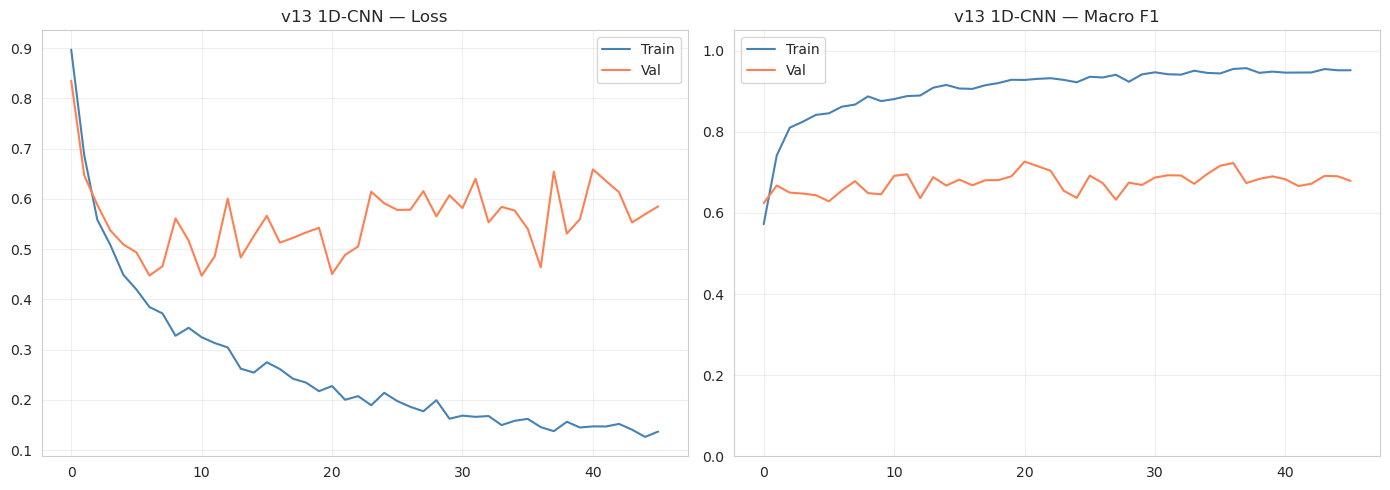

In [11]:
# Encode labels
le = LabelEncoder(); le.fit(CLASSES)
y_all = le.transform(all_labels_merged)

# StandardScaler on the sequences: fit on train, transform all
# We scale per-feature across all time steps
X_tr_raw = all_sequences[tr_m]  # (N_tr, 75, 13)
X_va_raw = all_sequences[va_m]
X_te_raw = all_sequences[te_m]

# Reshape to 2D for scaling, then reshape back
n_tr, seq, nf = X_tr_raw.shape
scaler = StandardScaler()
X_tr_flat = scaler.fit_transform(X_tr_raw.reshape(-1, nf))  # (N_tr*75, 13)
X_tr_s = X_tr_flat.reshape(n_tr, seq, nf).astype(np.float32)
X_va_s = scaler.transform(X_va_raw.reshape(-1, nf)).reshape(X_va_raw.shape[0], seq, nf).astype(np.float32)
X_te_s = scaler.transform(X_te_raw.reshape(-1, nf)).reshape(X_te_raw.shape[0], seq, nf).astype(np.float32)

y_tr, y_va, y_te = y_all[tr_m], y_all[va_m], y_all[te_m]

print(f'Train: {X_tr_s.shape}, Val: {X_va_s.shape}, Test: {X_te_s.shape}')
print(f'Train distribution:')
for i, name in enumerate(le.classes_):
    print(f'  {name}: {(y_tr==i).sum()}')

# Balanced sampler
cc = np.bincount(y_tr, minlength=NUM_CLASSES).astype(np.float64)
sw = (1.0/np.maximum(cc,1))[y_tr]; sw = sw/sw.sum()
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

dl_tr = DataLoader(TensorDataset(torch.FloatTensor(X_tr_s), torch.LongTensor(y_tr)), batch_size=BS, sampler=sampler)
dl_va = DataLoader(TensorDataset(torch.FloatTensor(X_va_s), torch.LongTensor(y_va)), batch_size=BS, shuffle=False)
dl_te = DataLoader(TensorDataset(torch.FloatTensor(X_te_s), torch.LongTensor(y_te)), batch_size=BS, shuffle=False)

# Train
MODEL_PATH = os.path.join(OUTPUT_DIR, f'model_best_{VER}.pth')
print(f'\nTraining {VER}...')
hist, best_f1 = train_model(model, dl_tr, dl_va, NUM_CLASSES, MODEL_PATH, lr=5e-4)
plot_curves(hist, f'{VER} 1D-CNN', f'{VER}_curves.png')

## Test Evaluation

Loaded from epoch 21 (val F1=0.7265)

v13 TEST RESULTS:
  Accuracy: 0.8313
  Macro F1: 0.6899

                  precision    recall  f1-score   support

       head_turn      0.494     0.614     0.548        70
lateral_movement      0.667     0.567     0.613        60
          normal      0.918     0.901     0.909       445

        accuracy                          0.831       575
       macro avg      0.693     0.694     0.690       575
    weighted avg      0.840     0.831     0.834       575



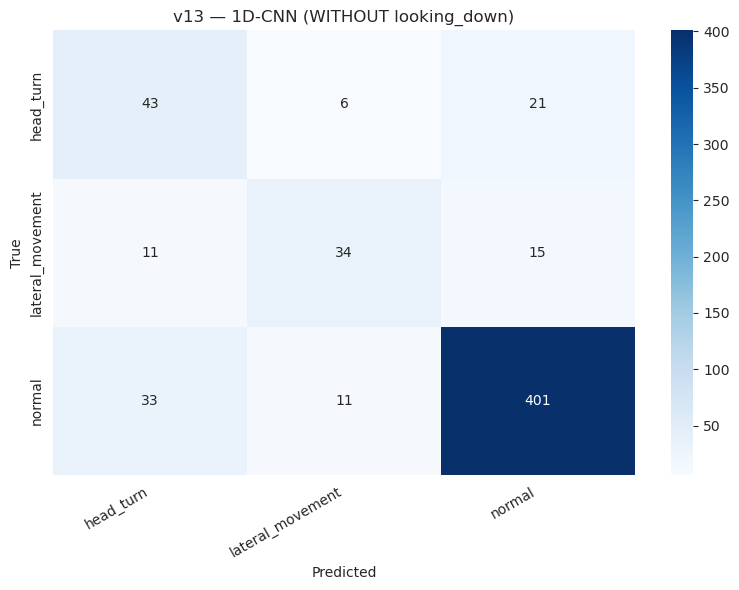

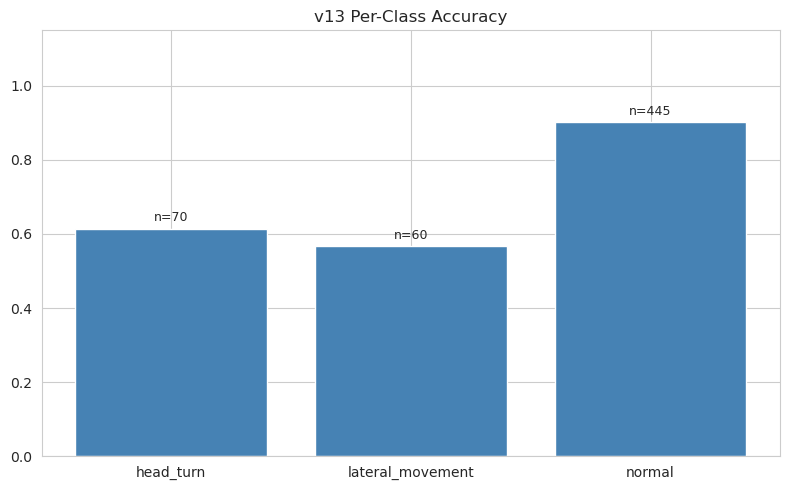


v13 DONE. Macro F1 = 0.6899


In [12]:
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(ckpt['state_dict']); model.eval()
print(f'Loaded from epoch {ckpt["epoch"]+1} (val F1={ckpt["val_f1"]:.4f})')

preds, trues = [], []
with torch.no_grad():
    for xb, yb in dl_te:
        out = model(xb.to(device))
        preds.extend(out.argmax(1).cpu().numpy()); trues.extend(yb.numpy())
preds, trues = np.array(preds), np.array(trues)

acc = accuracy_score(trues, preds)
f1 = f1_score(trues, preds, average='macro', zero_division=0)
print(f'\n{VER} TEST RESULTS:')
print(f'  Accuracy: {acc:.4f}')
print(f'  Macro F1: {f1:.4f}')
print(f'\n{classification_report(trues, preds, target_names=le.classes_, digits=3, zero_division=0)}')

cm = confusion_matrix(trues, preds)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'{VER} — 1D-CNN (WITHOUT looking_down)'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f'{VER}_cm.png'), dpi=150, bbox_inches='tight'); plt.show()

# Per-class accuracy
fig, ax = plt.subplots(figsize=(8,5))
for i, name in enumerate(le.classes_):
    m = trues == i
    if m.sum() > 0:
        ca = (preds[m]==i).mean()
        ax.bar(name, ca, color='steelblue')
        ax.text(i, ca+0.02, f'n={m.sum()}', ha='center', fontsize=9)
ax.set_title(f'{VER} Per-Class Accuracy'); ax.set_ylim(0,1.15)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, f'{VER}_per_class.png'), dpi=150, bbox_inches='tight'); plt.show()

print(f'\n{VER} DONE. Macro F1 = {f1:.4f}')